# Experiment 5.5.1 — Regularized Semantic WHEN

**Analysis-only notebook.** The validation selector and finalizer are external experiment stages. This notebook only reads finalized CSV/JSON artifacts; missing artifacts are treated as an incomplete experiment and are never regenerated here.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    path = start.resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'AGENTS.md').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root')

repo_root = find_repo_root()
root = repo_root / 'notebooks' / 'artifacts' / 'experiment_5_5_1_regularized_semantic_when' / 'regularized_semantic_when_v1'
required = [
    'screen_runs.csv', 'screen_summary.csv', 'screen_paired_deltas.csv', 'selection.json',
    'final_runs.csv', 'final_summary.csv', 'final_paired_deltas.csv',
    'progress_metrics.csv', 'state_diagnostics.csv', 'state_profiles.csv',
    'q_only_probes.csv', 'q_progress_probe.csv', 'shuffled_q.csv',
    'same_what_pairs.csv', 'matched_progress_same_what.csv', 'manifest.json',
]
missing = [name for name in required if not (root / name).exists()]
if missing:
    raise FileNotFoundError(f'Exp5.5.1 is not finalized; missing artifacts: {missing}')

screen_runs = pd.read_csv(root / 'screen_runs.csv')
screen_summary = pd.read_csv(root / 'screen_summary.csv')
screen_paired = pd.read_csv(root / 'screen_paired_deltas.csv')
selection = json.loads((root / 'selection.json').read_text())
final_runs = pd.read_csv(root / 'final_runs.csv')
final_summary = pd.read_csv(root / 'final_summary.csv')
final_paired = pd.read_csv(root / 'final_paired_deltas.csv')
progress = pd.read_csv(root / 'progress_metrics.csv')
state_diag = pd.read_csv(root / 'state_diagnostics.csv')
state_profiles = pd.read_csv(root / 'state_profiles.csv')
q_only = pd.read_csv(root / 'q_only_probes.csv')
q_progress = pd.read_csv(root / 'q_progress_probe.csv')
shuffled = pd.read_csv(root / 'shuffled_q.csv')
same_what = pd.read_csv(root / 'same_what_pairs.csv')
matched_progress_same_what = pd.read_csv(root / 'matched_progress_same_what.csv')
manifest = json.loads((root / 'manifest.json').read_text())
root

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_5_5_1_regularized_semantic_when/regularized_semantic_when_v1')

## Validation-only recipe screen

In [2]:
display(pd.DataFrame([selection]))
display(screen_summary.sort_values('complexity'))
display(screen_paired.groupby('recipe')['delta_val_balanced_accuracy_vs_ce_only'].agg(['mean', 'std', 'min', 'max']))

,eligibility_rule,experiment_id,protocol_version,regularization_rescue_supported,screen_paired_deltas,screen_runs,screen_summary,selected_recipe,selected_recipe_parameters,selection_rule,test_used_for_recipe_selection
0,mean paired val BA delta > 0 and >=4/5 seed de...,experiment_5_5_1_regularized_semantic_when,regularized_semantic_when_v1,True,notebooks/artifacts/experiment_5_5_1_regulariz...,notebooks/artifacts/experiment_5_5_1_regulariz...,notebooks/artifacts/experiment_5_5_1_regulariz...,progress,"{'complexity': 1, 'lambda_confidence': 0.0, 'l...","among eligible recipes, choose lowest-complexi...",False


,recipe,complexity,mean_val_balanced_accuracy,sd_val_balanced_accuracy,sem_val_balanced_accuracy,mean_delta_vs_ce_only,nonnegative_seed_count,eligible
0,progress,1,0.552208,0.014173,0.006339,0.013765,4,True
1,progress_sticky,2,0.549567,0.011959,0.005348,0.011124,3,False
2,progress_sticky_confidence,3,0.558306,0.014833,0.006634,0.019863,5,True


,mean,std,min,max
recipe,,,,
progress,0.013765,0.013818,-0.007864,0.024008
progress_sticky,0.011124,0.015123,-0.005381,0.032341
progress_sticky_confidence,0.019863,0.010909,0.002652,0.032341


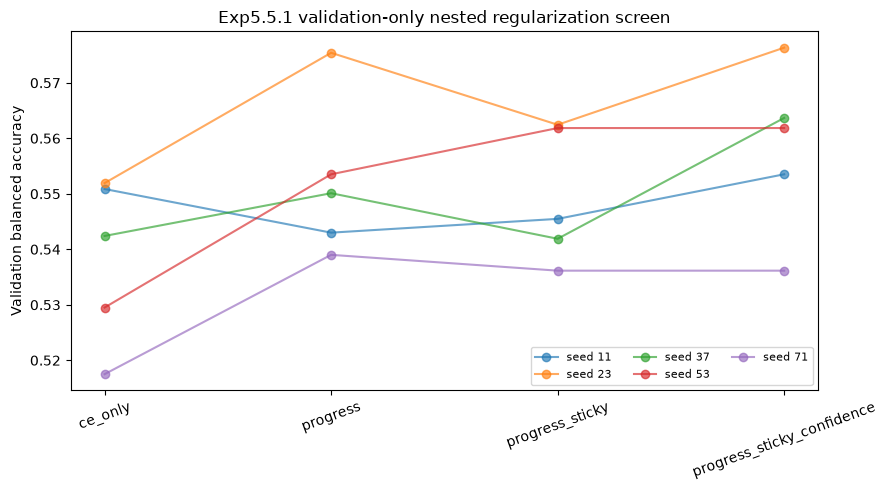

In [3]:
order = ['ce_only', 'progress', 'progress_sticky', 'progress_sticky_confidence']
pivot = screen_runs.pivot(index='seed', columns='recipe', values='val_balanced_accuracy')
fig, ax = plt.subplots(figsize=(9, 5))
for seed, row in pivot.iterrows():
    x = [name for name in order if name in row.index]
    ax.plot(x, [row[name] for name in x], marker='o', alpha=0.65, label=f'seed {seed}')
ax.set_ylabel('Validation balanced accuracy')
ax.set_title('Exp5.5.1 validation-only nested regularization screen')
ax.tick_params(axis='x', rotation=20)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()

## Final classification results

In [4]:
display(final_summary.sort_values('mean_test_balanced_accuracy', ascending=False))
display(final_paired.groupby('comparison')['delta_test_balanced_accuracy'].agg(['mean', 'std', 'min', 'max']))

,condition,n_runs,mean_test_balanced_accuracy,sd_test_balanced_accuracy,sem_test_balanced_accuracy,mean_test_accuracy,mean_test_macro_f1
5,fixed250,5,0.595230,0.009826,0.004394,0.608219,0.595250
2,oracle_progress,5,0.571931,0.036235,0.016205,0.582192,0.568902
1,clock,5,0.550074,0.037300,0.016681,0.557534,0.538569
7,reg_reset,5,0.525130,0.034828,0.015576,0.531507,0.519478
6,reg_ordered,5,0.519932,0.029992,0.013413,0.526027,0.512421
8,reg_ordered_shuffled_q,5,0.511918,0.013403,0.005994,0.516438,0.503185
3,ce_reset,5,0.503003,0.029939,0.013389,0.509589,0.495397
4,ce_ordered,5,0.489864,0.035321,0.015796,0.494521,0.480491
0,shared,5,0.444682,0.034719,0.015527,0.449315,0.441177


,mean,std,min,max
comparison,,,,
reg_ordered_minus_ce_ordered,0.030068,0.027461,-0.005952,0.059386
reg_ordered_minus_clock,-0.030143,0.030331,-0.059980,0.010507
reg_ordered_minus_fixed250,-0.075299,0.037573,-0.125413,-0.036373
reg_ordered_minus_oracle_progress,-0.052000,0.049235,-0.137025,-0.018887
reg_ordered_minus_reg_reset,-0.005198,0.039173,-0.045743,0.055996
reg_ordered_minus_shuffled_q,0.008013,0.016667,-0.012633,0.025345


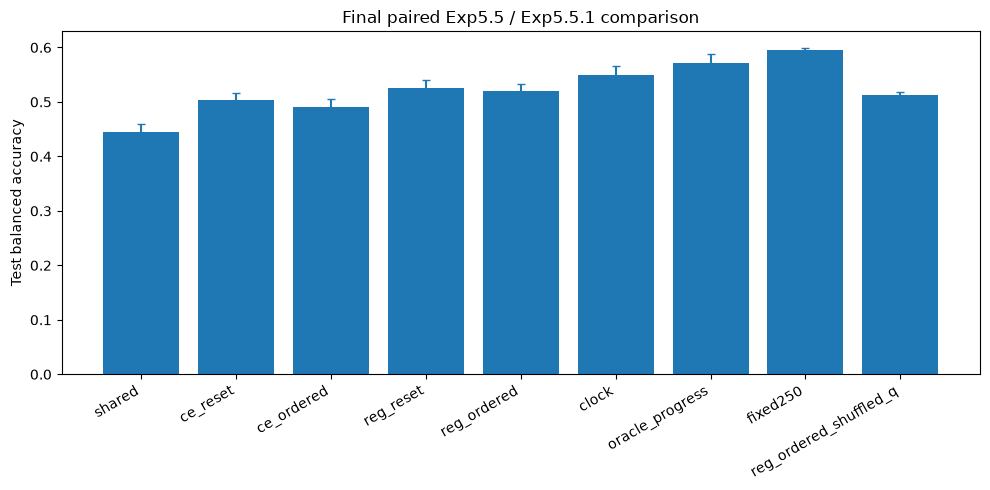

In [5]:
plot_order = ['shared', 'ce_reset', 'ce_ordered', 'reg_reset', 'reg_ordered', 'clock', 'oracle_progress', 'fixed250', 'reg_ordered_shuffled_q']
plot_frame = final_summary.set_index('condition').reindex(plot_order).dropna(how='all')
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(np.arange(len(plot_frame)), plot_frame['mean_test_balanced_accuracy'])
ax.errorbar(np.arange(len(plot_frame)), plot_frame['mean_test_balanced_accuracy'], yerr=plot_frame['sem_test_balanced_accuracy'], fmt='none', capsize=3)
ax.set_xticks(np.arange(len(plot_frame)), plot_frame.index, rotation=30, ha='right')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Final paired Exp5.5 / Exp5.5.1 comparison')
plt.tight_layout()

## Progress auxiliary diagnostics

In [6]:
display(progress[progress['split'] == 'test'].sort_values(['condition', 'seed']))
display(progress[progress['split'] == 'test'].groupby('condition')[['mae', 'rmse', 'r2', 'spearman', 'coarse_10bin_accuracy']].mean())

,condition,seed,split,coarse_10bin_accuracy,mae,n_timesteps,pearson,r2,rmse,spearman
0,reg_ordered,11,test,0.293820,0.117375,12072,0.852040,0.717990,0.155167,0.847701
6,reg_ordered,23,test,0.297300,0.117289,12072,0.856515,0.719099,0.154861,0.847939
12,reg_ordered,37,test,0.294400,0.117032,12072,0.870596,0.723144,0.153742,0.865976
18,reg_ordered,53,test,0.171885,0.170542,12072,0.727458,0.493225,0.208005,0.717313
24,reg_ordered,71,test,0.228463,0.133881,12072,0.813491,0.654436,0.171764,0.804245
3,reg_reset,11,test,0.202369,0.148104,12072,0.787901,0.614244,0.181478,0.793953
9,reg_reset,23,test,0.165176,0.169568,12072,0.751676,0.512328,0.204047,0.750221
15,reg_reset,37,test,0.158300,0.178251,12072,0.717572,0.465801,0.213559,0.720333
21,reg_reset,53,test,0.182571,0.152977,12072,0.782918,0.600015,0.184794,0.790728
27,reg_reset,71,test,0.210073,0.134653,12072,0.817609,0.665215,0.169063,0.822758


,mae,rmse,r2,spearman,coarse_10bin_accuracy
condition,,,,,
reg_ordered,0.131224,0.168708,0.661579,0.816635,0.257174
reg_reset,0.156710,0.190588,0.571521,0.775598,0.183698


## Semantic state geometry and persistence

In [7]:
key_metrics = ['entropy_mean', 'total_variation_l1_mean', 'argmax_transitions_per_second', 'mean_dwell_seconds']
display(state_diag[state_diag['metric'].isin(key_metrics)].pivot_table(index='condition', columns='metric', values='value', aggfunc='mean'))

metric,argmax_transitions_per_second,entropy_mean,mean_dwell_seconds,total_variation_l1_mean
condition,,,,
reg_ordered,7.960557,1.895226,0.126758,0.062877
reg_reset,21.798424,1.970753,0.046199,0.164861


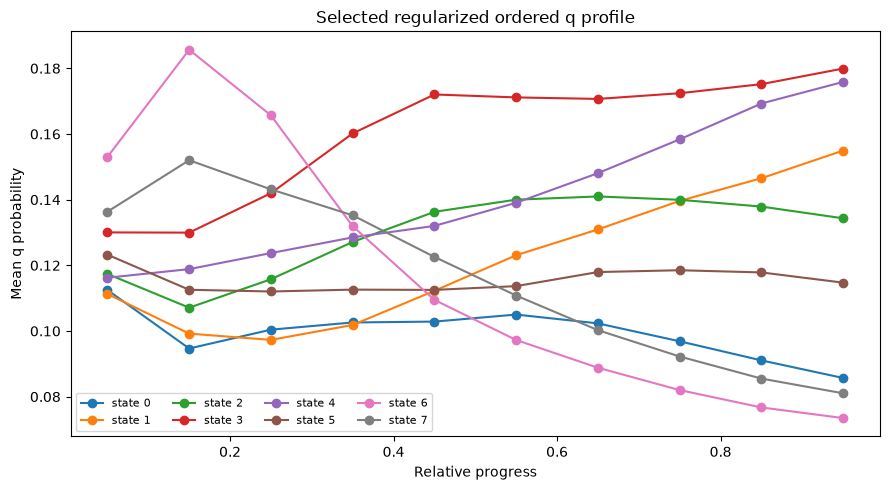

In [8]:
profile = state_profiles[(state_profiles['condition'] == 'reg_ordered') & (state_profiles['axis'] == 'relative_progress')]
profile_mean = profile.groupby(['position', 'state'], as_index=False)['probability'].mean()
fig, ax = plt.subplots(figsize=(9, 5))
for state, group in profile_mean.groupby('state'):
    ax.plot(group['position'], group['probability'], marker='o', label=f'state {int(state)}')
ax.set_xlabel('Relative progress')
ax.set_ylabel('Mean q probability')
ax.set_title('Selected regularized ordered q profile')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()

## Class-code and progress-code checks

In [9]:
display(q_only[q_only['split'] == 'test'].pivot_table(index=['condition', 'seed'], columns='feature', values='balanced_accuracy'))
display(q_progress.sort_values(['condition', 'seed']))

feature            final_q    mean_q
condition   seed                    
reg_ordered 11    0.389467  0.415528
            23    0.434972  0.481211
            37    0.375137  0.363117
            53    0.385990  0.430782
            71    0.430178  0.445346
reg_reset   11    0.234273  0.427713
            23    0.263360  0.476261
            37    0.213098  0.429290
            53    0.351767  0.442514
            71    0.287463  0.463437

,condition,seed,n_test_timesteps,n_train_timesteps,probe,test_q_mae,test_r2_uniform_average
0,reg_ordered,11,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.058622,0.088755
2,reg_ordered,23,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.049008,0.218815
4,reg_ordered,37,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.055597,0.168004
6,reg_ordered,53,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.025703,0.190750
8,reg_ordered,71,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.035619,0.196396
1,reg_reset,11,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.039776,0.129010
3,reg_reset,23,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.020940,0.189615
5,reg_reset,37,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.014331,0.139593
7,reg_reset,53,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.033802,0.129449
9,reg_reset,71,12072,50000,"Ridge(true_relative_progress -> q), train-fit/...",0.045385,0.131454


## Same-WHAT / different-history mechanism checks

In [10]:
print('same-WHAT rows:', len(same_what))
print('same-WHAT + matched-progress rows:', len(matched_progress_same_what))
if not same_what.empty:
    display(same_what.sort_values(['what_cosine_similarity', 'q_l1_distance'], ascending=False).head(30))
if not matched_progress_same_what.empty:
    display(matched_progress_same_what.sort_values(['what_cosine_similarity', 'q_l1_distance'], ascending=False).head(30))

same-WHAT rows: 500
same-WHAT + matched-progress rows: 16


,seed,sample_a,timestep_a,label_a,sample_b,timestep_b,label_b,what_cosine_similarity,q_l1_distance,evidence_l1_distance,top_support_a,top_support_b,different_top_support,high_similarity
0,11,55,14,4,103,3,5,1.0,0.430050,0.038103,11,8,True,True
200,37,25,16,2,103,7,5,1.0,0.304579,0.043556,3,3,False,True
1,11,76,28,1,130,64,7,1.0,0.233038,0.034708,8,8,False,True
2,11,76,7,1,130,64,7,1.0,0.227530,0.026026,8,8,False,True
3,11,76,16,1,130,64,7,1.0,0.193172,0.030687,8,8,False,True
4,11,76,19,1,130,64,7,1.0,0.185247,0.029115,8,8,False,True
5,11,130,64,7,80,37,2,1.0,0.181259,0.029260,8,8,False,True
6,11,103,7,5,122,8,2,1.0,0.128451,0.013254,7,7,False,True
400,71,63,16,10,46,62,3,1.0,0.115667,0.011230,8,8,False,True
7,11,80,43,2,76,28,1,1.0,0.105234,0.010165,8,8,False,True


,seed,sample_a,timestep_a,label_a,sample_b,timestep_b,label_b,what_cosine_similarity,q_l1_distance,evidence_l1_distance,top_support_a,top_support_b,different_top_support,high_similarity,progress_a,progress_b,progress_abs_delta
5,37,122,8,2,115,12,4,1.0,0.103717,0.021126,8,8,False,True,0.153846,0.146341,0.007505
2,23,88,11,3,105,13,1,1.0,0.088687,0.010080,11,11,False,True,0.134146,0.132653,0.001493
8,71,76,26,1,139,19,4,1.0,0.058569,0.008393,8,8,False,True,0.214876,0.211111,0.003765
6,37,132,13,6,101,12,1,1.0,0.047803,0.006370,2,2,False,True,0.152941,0.107143,0.045798
0,11,139,19,4,128,13,5,1.0,0.043732,0.004048,5,5,False,True,0.211111,0.162500,0.048611
3,23,100,12,6,84,10,0,1.0,0.031378,0.002172,5,5,False,True,0.116505,0.112360,0.004145
7,53,56,5,3,31,9,5,1.0,0.023519,0.002738,6,6,False,True,0.064103,0.080357,0.016255
9,71,139,21,4,108,14,2,1.0,0.020886,0.003515,2,2,False,True,0.233333,0.254545,0.021212
10,71,135,13,2,139,17,4,1.0,0.019353,0.003110,2,2,False,True,0.224138,0.188889,0.035249
11,71,139,17,4,141,13,1,1.0,0.019353,0.003110,2,2,False,True,0.188889,0.147727,0.041162


## Interpretation checklist

Primary rescue requires `reg_ordered > ce_ordered`, `reg_ordered > reg_reset`, and `reg_ordered > reg_ordered_shuffled_q`. Clock/oracle comparisons determine whether the learned WHEN is merely an internal phase estimator or captures additional history-conditioned structure. The progress-to-q Ridge diagnostic and matched-progress same-WHAT table should be consulted before describing q as semantic state rather than a progress code.